<a href="https://colab.research.google.com/github/173teja-rgb/Machine-learning-lab/blob/main/150_ml_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("train.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Saving train.csv to train (1).csv
Dataset loaded successfully
Shape: (1197, 15)


In [13]:
print(df.head())
print("\nColumns:")
print(df.columns.tolist())

       date   quarter  department       day  team  targeted_productivity  \
0  1/1/2015  Quarter1      sweing  Thursday     8                   0.80   
1  1/1/2015  Quarter1  finishing   Thursday     1                   0.75   
2  1/1/2015  Quarter1      sweing  Thursday    11                   0.80   
3  1/1/2015  Quarter1      sweing  Thursday    12                   0.80   
4  1/1/2015  Quarter1      sweing  Thursday     6                   0.80   

     smv     wip  over_time  incentive  idle_time  idle_men  \
0  26.16  1108.0       7080         98        0.0         0   
1   3.94     NaN        960          0        0.0         0   
2  11.41   968.0       3660         50        0.0         0   
3  11.41   968.0       3660         50        0.0         0   
4  25.90  1170.0       1920         50        0.0         0   

   no_of_style_change  no_of_workers  actual_productivity  
0                   0           59.0             0.940725  
1                   0            8.0        

In [14]:
features = [
    'targeted_productivity',
    'smv',
    'wip',
    'over_time',
    'incentive',
    'no_of_workers'
]

X = df[features].fillna(0)
y = df['actual_productivity'].fillna(df['actual_productivity'].median())

print("Features:", features)
print("Target: actual_productivity")

Features: ['targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'no_of_workers']
Target: actual_productivity


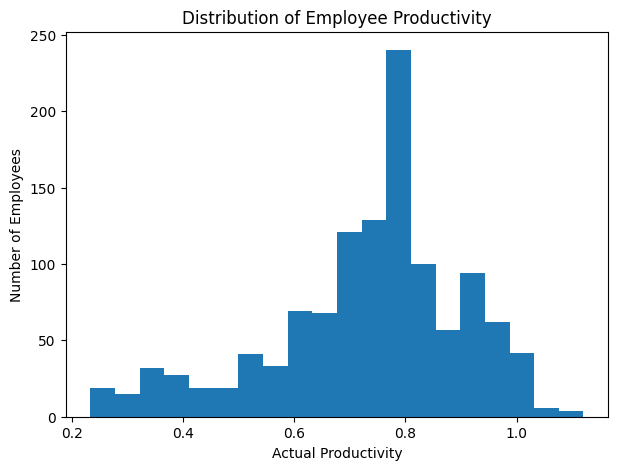

In [15]:
plt.figure(figsize=(7,5))
plt.hist(y, bins=20)
plt.xlabel("Actual Productivity")
plt.ylabel("Number of Employees")
plt.title("Distribution of Employee Productivity")
plt.show()

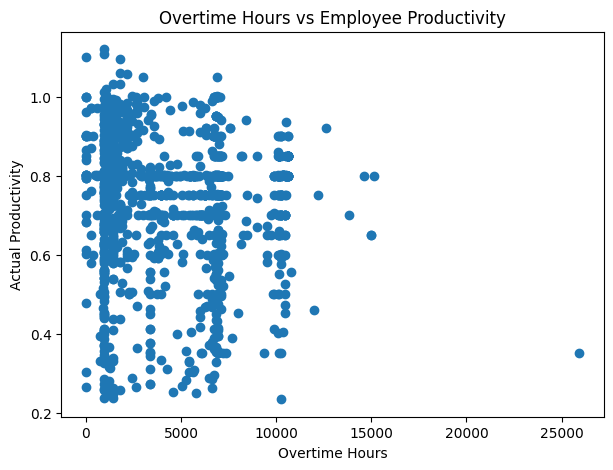

In [16]:
plt.figure(figsize=(7,5))
plt.scatter(df['over_time'], y)
plt.xlabel("Overtime Hours")
plt.ylabel("Actual Productivity")
plt.title("Overtime Hours vs Employee Productivity")
plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 957
Testing samples: 240


In [18]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest Regressor trained successfully")

Random Forest Regressor trained successfully


In [19]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", round(rmse, 4))
print("R2 Score:", round(r2, 4))

RMSE: 0.114
R2 Score: 0.5109


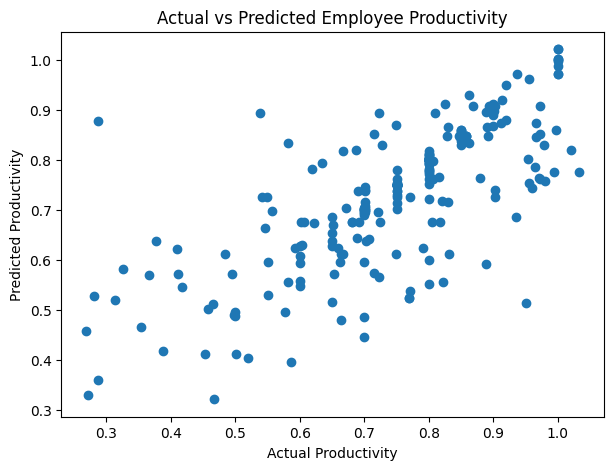

In [20]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Actual vs Predicted Employee Productivity")
plt.show()

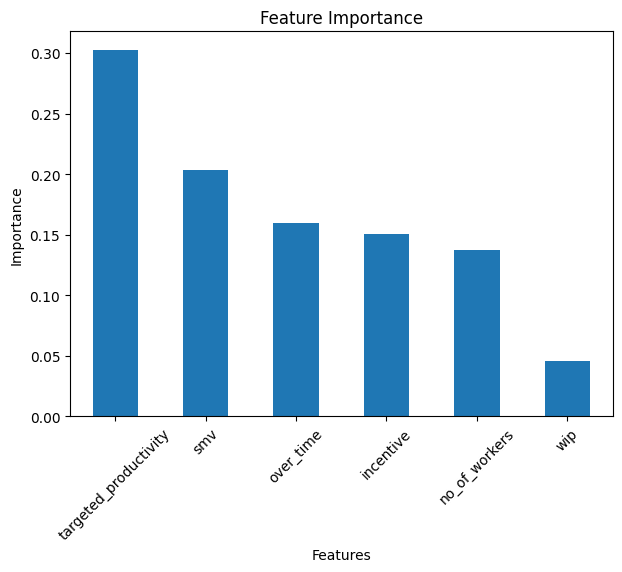

In [21]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(7,5))
importance.plot(kind='bar')
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [22]:
new_employee = pd.DataFrame([{
    'targeted_productivity': 0.80,
    'smv': 20,
    'wip': 100,
    'over_time': 500,
    'incentive': 20,
    'no_of_workers': 55
}])

prediction = model.predict(new_employee)[0]

print("Predicted Productivity:", round(prediction, 3))
print("Predicted Productivity (%):", round(prediction * 100, 2), "%")

Predicted Productivity: 0.688
Predicted Productivity (%): 68.84 %
